In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cmocean 
import wocemaps as wm
import momlevel as ml
import cftime
import gsw
import cartopy.crs as ccrs

### load time mean global Temerpature (T) and Salinity (S) (function of latitude, longitude, and depth)

In [2]:
woa18_data = xr.open_zarr('/home/tu.temple.edu/tuk08919/Data/OCEAN/physical_oceanography/data/woa18_full_decadal_ave_fields')

# ocean depth
etopo5_data = xr.open_dataset('http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NGDC/.ETOPO5/dods')
etopo5_data = etopo5_data.rename({'X': 'lon', 'Y': 'lat'})
etopo5_data['elev_ocean'] = etopo5_data.elev.where(etopo5_data.elev<0).load()
etopo5_data

<xarray.Dataset>
Dimensions:     (lon: 4320, lat: 2160)
Coordinates:
  * lon         (lon) float32 0.0 0.08333 0.1667 0.25 ... 359.8 359.8 359.9
  * lat         (lat) float32 90.0 89.92 89.83 89.75 ... -89.75 -89.83 -89.92
Data variables:
    elev        (lat, lon) int16 -4290 -4290 -4290 -4290 ... 2774 2774 2774 2774
    elev_ocean  (lat, lon) float64 -4.29e+03 -4.29e+03 -4.29e+03 ... nan nan nan
Attributes:
    dataset_documentation.html:  http://iridl.ldeo.columbia.edu/SOURCES/.NOAA...
    Conventions:                 IRIDL
    description:                 ETOPO5 5x5 minute land surface elevations an...

In [3]:
# key fields we'll be working with
temp = woa18_data.temp
salt = woa18_data.salinity
depth = woa18_data.depth
elev = etopo5_data.elev
elev_ocean = etopo5_data.elev_ocean

## In this exercise, we are going to use global fields of T and S to:

- compute potential density
- estimate horizontal density gradients
- leverage the thermal wind relation to estimate geostrophic velocities associated with density gradients

We'll walk through a procedure step by step and generate some figures to get a sense of the distributions of temperature, salinity, and density throughout the ocean

### todo: Using the gibbs seawater package (gsw), compute at all latitudes, longitudes, and depths potential density referenced to the surface (sigma0). 

This will first require calculations of absolute salinity and conservative temperature. Remember sigma references some density - 1000 km/m^3.

In [4]:
pressure = (gsw.p_from_z(-depth, woa18_data.lat))

poto_temp = gsw.pt_from_t(salt, temp, pressure, 0)
cons_temp = gsw.CT_from_t(salt, temp, pressure) 

abs_salt = gsw.SA_from_SP(salt, pressure, woa18_data.lon, woa18_data.lat)

In [5]:
sigma_0 = gsw.pot_rho_t_exact(abs_salt, cons_temp, pressure, 0)-1000

### todo: Using cartopy produce a global map of T, S and potential density at the surface and at 1000m depth. 

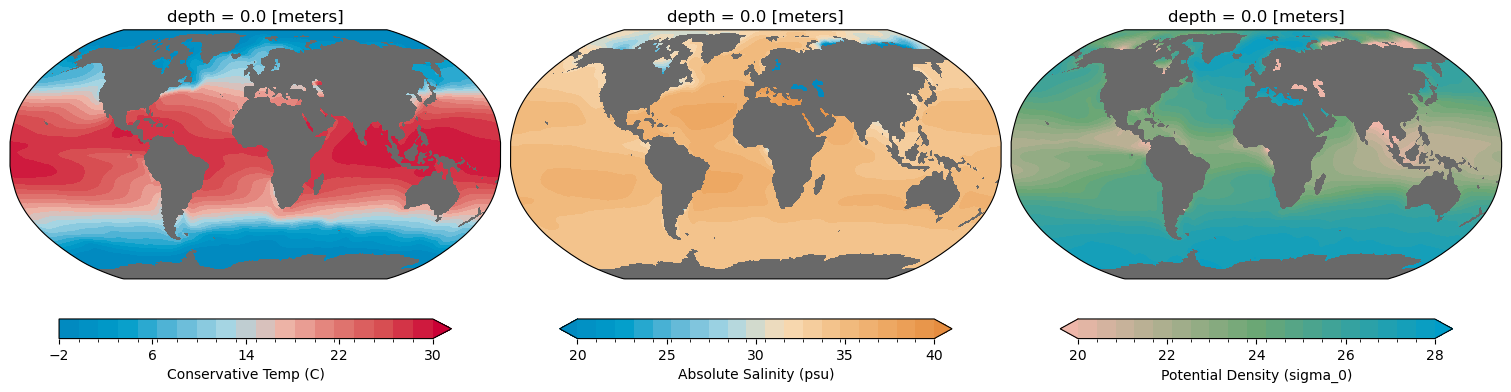

In [6]:
fig, ax = plt.subplots(figsize=(15,8), ncols=3, 
                       layout='constrained',
                       subplot_kw={'projection':ccrs.Robinson(),
                                   'facecolor':'dimgrey'},
                           )

cons_temp.isel(depth=0).plot.contourf(x='lon', y='lat',
                             ax=ax[0],
                                     levels=20,
                                      vmin=-2,
                                      vmax=30,
                                      cmap=wm.potentialtemp,
                             transform=ccrs.PlateCarree(),
                             cbar_kwargs={'shrink':0.8,
                                          'orientation':'horizontal',
                                         'label':"Conservative Temp (C)",
                                         'ticks':np.linspace(-2,30,5)}
                                    )

abs_salt.isel(depth=0).plot.contourf(x='lon', y='lat',
                             ax=ax[1],
                                 levels=20,
                                 vmin=20,
                                 vmax=40,
                                 cmap=wm.salinity,
                             transform=ccrs.PlateCarree(),
                             cbar_kwargs={'shrink':0.8,
                                          'orientation':'horizontal',
                                         'label':"Absolute Salinity (psu)",
                                         'ticks':np.linspace(20,40,5)})

sigma_0.isel(depth=0).plot.contourf(x='lon', y='lat',
                             ax=ax[2],
                                    levels=20,
                                 vmin=20,
                                 vmax=28,
                                    cmap=wm.pdensity,
                             transform=ccrs.PlateCarree(),
                             cbar_kwargs={'shrink':0.8,
                                          'orientation':'horizontal',
                                         'label':"Potential Density (sigma_0)",
                                         'ticks':np.linspace(20,28,5)})


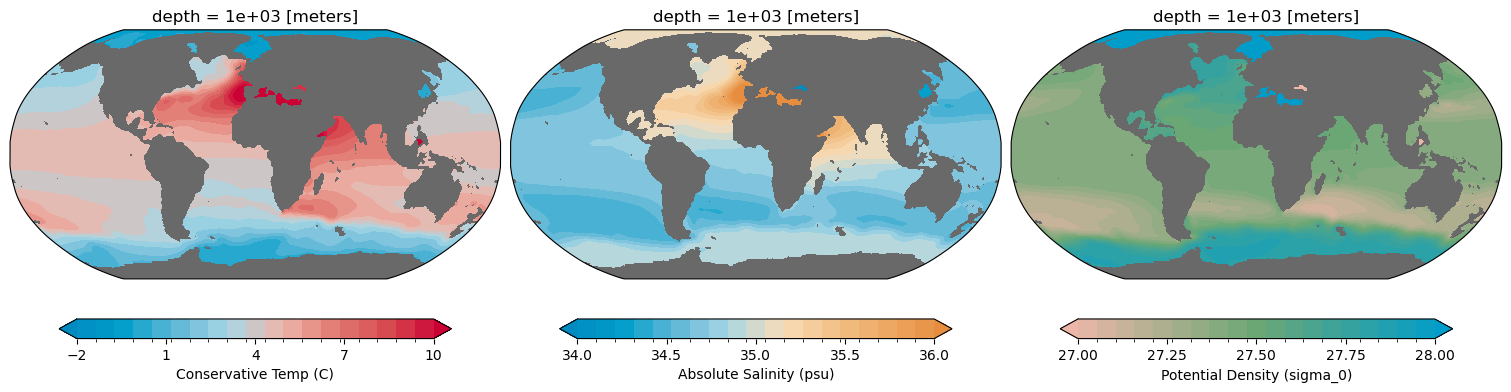

In [7]:
fig, ax = plt.subplots(figsize=(15,8), ncols=3, 
                       layout='constrained',
                       subplot_kw={'projection':ccrs.Robinson(),
                                   'facecolor':'dimgrey'},
                           )

cons_temp.sel(depth=1000).plot.contourf(x='lon', y='lat',
                             ax=ax[0],
                                     levels=20,
                                      vmin=-2,
                                      vmax=10,
                                      cmap=wm.potentialtemp,
                             transform=ccrs.PlateCarree(),
                             cbar_kwargs={'shrink':0.8,
                                          'orientation':'horizontal',
                                         'label':"Conservative Temp (C)",
                                         'ticks':np.linspace(-2,10,5)}
                                    )

abs_salt.sel(depth=1000).plot.contourf(x='lon', y='lat',
                             ax=ax[1],
                                 levels=20,
                                 vmin=34,
                                 vmax=36,
                                 cmap=wm.salinity,
                             transform=ccrs.PlateCarree(),
                             cbar_kwargs={'shrink':0.8,
                                          'orientation':'horizontal',
                                         'label':"Absolute Salinity (psu)",
                                         'ticks':np.linspace(34,36,5)})

sigma_0.sel(depth=1000).plot.contourf(x='lon', y='lat',
                             ax=ax[2],
                                    levels=20,
                                 vmin=27,
                                 vmax=28,
                                    cmap=wm.pdensity,
                             transform=ccrs.PlateCarree(),
                             cbar_kwargs={'shrink':0.8,
                                          'orientation':'horizontal',
                                         'label':"Potential Density (sigma_0)",
                                         'ticks':np.linspace(27,28,5)})


### todo: Write a few sentences about the patterns you observe (i.e. why is it warmer or saltier in certain regions?)

### <span style="color:green">Surface temperatures are warmest in the tropics, especially at the equator where solar radiation is highest.</span>

### <span style="color:green">Surface salinity is highest in the tropices, but closer to ~20ºN/S, not at the equator. ITCZ decreases salinity at the equator where temp is highest.</span> 

### <span style="color:green">Surface potential density is highest near the poles where air temperatures and ocean temperatures are lowest.</span> 

### todo: Plot a cross section of potential density at 30W longitude (across all latitudes)

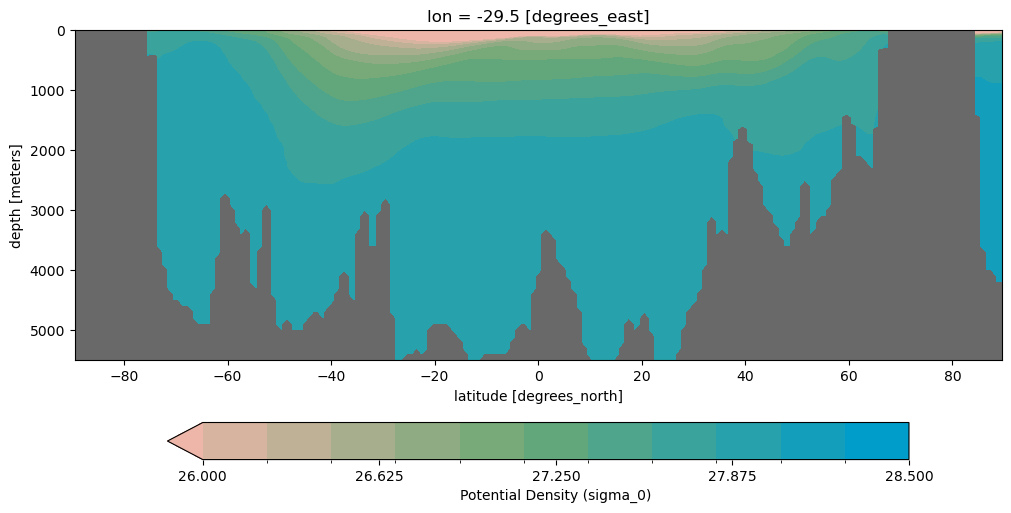

In [8]:
fig, ax = plt.subplots(figsize=(10,5),
                       layout='constrained',
                       subplot_kw={
                           # 'projection':ccrs.Robinson(),
                           'facecolor':'dimgrey'},
                           )

sigma_0.sel(lon=-30, method='nearest').plot.contourf(yincrease=False,
                                                     ax=ax,
                                                     levels=12,
                                                     vmin=26,
                                                     vmax=28.5,
                                                     cmap=wm.pdensity,
                                                     # transform=ccrs.PlateCarree(),
                                                     cbar_kwargs={'shrink':0.8,
                                                                  'orientation':'horizontal',
                                                                  'label':"Potential Density (sigma_0)",
                                                                  'ticks':np.linspace(26,28.5,5)})


### todo: Along this cross-section, estimate and plot horizontal gradients of potential density ($\frac{\partial \sigma_0}{\partial y}$) 

(consider using the centered difference method and ignoring the latitudes for which a centered difference would be incomplete)

In [9]:
sig_30W = sigma_0.sel(lon=-30, method='nearest')

In [10]:
# centered diff (1852 * 60 *) converts to meters
dy2 = (1852 * 60 * sig_30W.lat.values[2:]) - (1852 * 60 * sig_30W.lat.values[:-2])
# dy2 = np.ones_like(sig_30W) * dy2.max() # using max because all vals are the same

In [11]:
dsig0_30W_vals = sig_30W.values[:, 2:] - sig_30W.values[:, :-2]


In [12]:
dsig0_30W_idx = xr.DataArray(dsig0_30W_vals).rename({'dim_0':'depth_index',
                                                     'dim_1':'lat_index'})

dsig0_30W = (dsig0_30W_idx.assign_coords({
    'depth_index': ('depth_index', sig_30W.depth.values),
    'lat_index': ('lat_index', sig_30W.lat.values[1:-1]) # sliceing to match len bc of center dif method
})
             .rename({'depth_index': 'depth', 'lat_index': 'lat'}))

In [13]:
dy2.max()

222240.0

In [14]:
dsig0_30W_dy = xr.DataArray(
    (dsig0_30W / dy2.max()) # max because all dy are the same
)
    

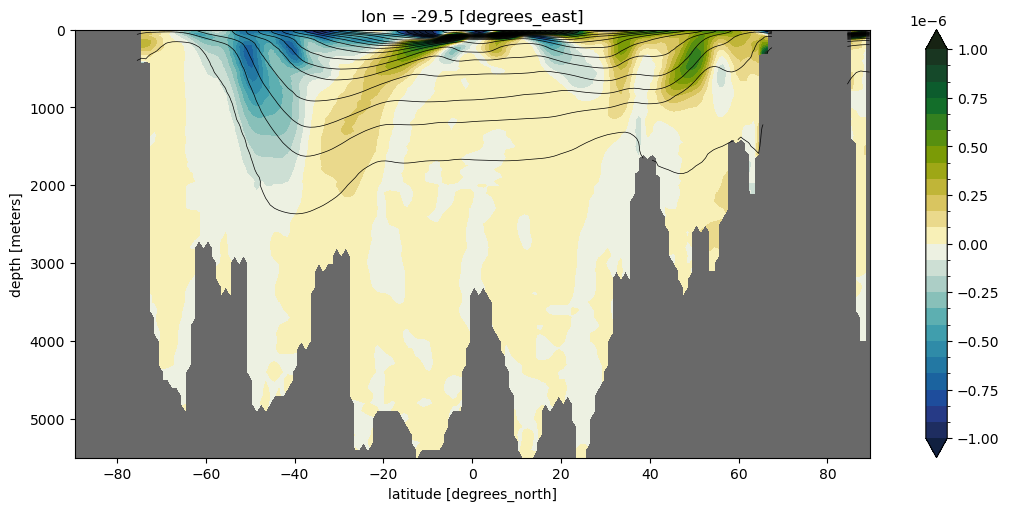

In [15]:
fig, ax = plt.subplots(figsize=(10,5),
                       layout='constrained',
                       subplot_kw={
                           'facecolor':'dimgrey'},
                           )

dsig0_30W_dy.plot.contourf(yincrease=False,
                           vmax=1e-6,
                           vmin=-1e-6,
                           levels=25,
                           cmap=cmocean.cm.delta)

sig_30W.plot.contour(levels=30, linewidths=0.5, colors='k', yincrease=False)


### with horizontal gradients of potential density, we can estimate the vertical shear of zonal velocities as

$\Large\frac{\partial u}{\partial z} = \frac{g}{\rho_0 f} \frac{\partial \sigma_0}{\partial y}$

todo: evaluate the right hand side (compute and plot $\frac{\partial u}{\partial z}$)

In [16]:
g = 9.81 #m/s2
rho_0 = 1035 #kg/m3
f = ml.derived.calc_coriolis(dsig0_30W_dy.lat) 

du_dz30W = (g/(rho_0*f))*dsig0_30W_dy

In [18]:
du_dz30W

<xarray.DataArray (lat: 178, depth: 102)>
array([[           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       ...,
       [3.57424789e-05, 4.35596076e-05, 6.30361114e-05, ...,
                   nan,            nan,            nan],
       [4.29289451e-05, 5.39838699e-05, 7.93834811e-05, ...,
                   nan,            nan,            nan],
       [7.40968173e-05, 7.93509336e-05, 1.17843773e-04, ...,
                   nan,            nan,            nan]])
Coordinates:
  * lat      (lat) float32 -88.5 -87.5 -86.5 -85.5 -84.5 ... 85.5 86.5 87.5 88.5
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03

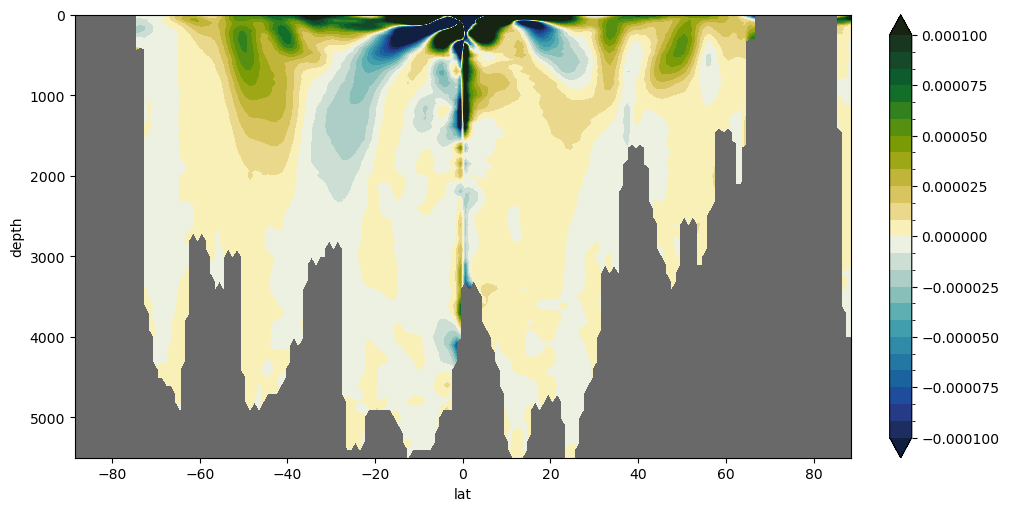

In [27]:
fig, ax = plt.subplots(figsize=(10,5),
                       layout='constrained',
                       subplot_kw={
                           'facecolor':'dimgrey'},
                           )

du_dz30W.plot.contourf(x='lat',
                       y='depth',
                       yincrease=False,
                       vmax=1e-4,
                       vmin=-1e-4,
                       levels=25,
                       cmap=cmocean.cm.delta)

### todo: select 1000 m as your reference level (or level of no motion) and cumulatively integrate from z = -1000 m to the surface to obtain a profile of zonal velocity $u$

We'll first ignore everything below z = -1000 m and assume $u$ is zero at z = -1000 m. At each latitude, calculate a cumulative vertical  sum of the right hand side, at each level multiplied by $dz$ (the vertical distance separating values), upwards from z = -1000 m ... this approximates a $du$ that when cumulatively summed approximated the total vertical integral.

todo: plot $u$ over this cross-section and across this depth range (spanning all latitudes between z = 0 m and z = -1000 m)

In [33]:
# step 1: ignore below 1000 m
du_dz30W_upper1000 = du_dz30W.sel(depth=slice(0,1000))

# step 2: vertical sum from 1000 to surface at all lats
du_dz30W_upper1000_flip = du_dz30W_upper1000.sortby('depth', ascending=False) # reverse z to integ from bottom to top
du_dz30W_upper1000_integ = du_dz30W_upper1000_flip.cumsum('depth')

# step 3: mult right side (above) by dz
dz_upper1000_idx = xr.DataArray((du_dz30W_upper1000.depth.values[2:] - du_dz30W_upper1000.depth.values[:-2])).rename({'dim_0': 'depth_index'}) # center dif dz
dz_upper1000 = (dz_upper1000_idx.assign_coords({
    'depth_index': ('depth_index', du_dz30W_upper1000.depth.values[1:-1]) # sliceing to match len bc of center dif method
}).rename({'depth_index': 'depth'})).depth

u30W_upper1000 = du_dz30W_upper1000_integ[:,1:-1] * dz_upper1000.sortby('depth', ascending=False).values # sel all lats and centered dif z spots to match dz
                                                                    # flipping dz to match order of du_dz30W_upper1000_integ
u30W_upper1000 = u30W_upper1000.where(sig_30W.notnull()) # mask out nans for land

Text(0.5, 1.0, 'dsig0_dy')

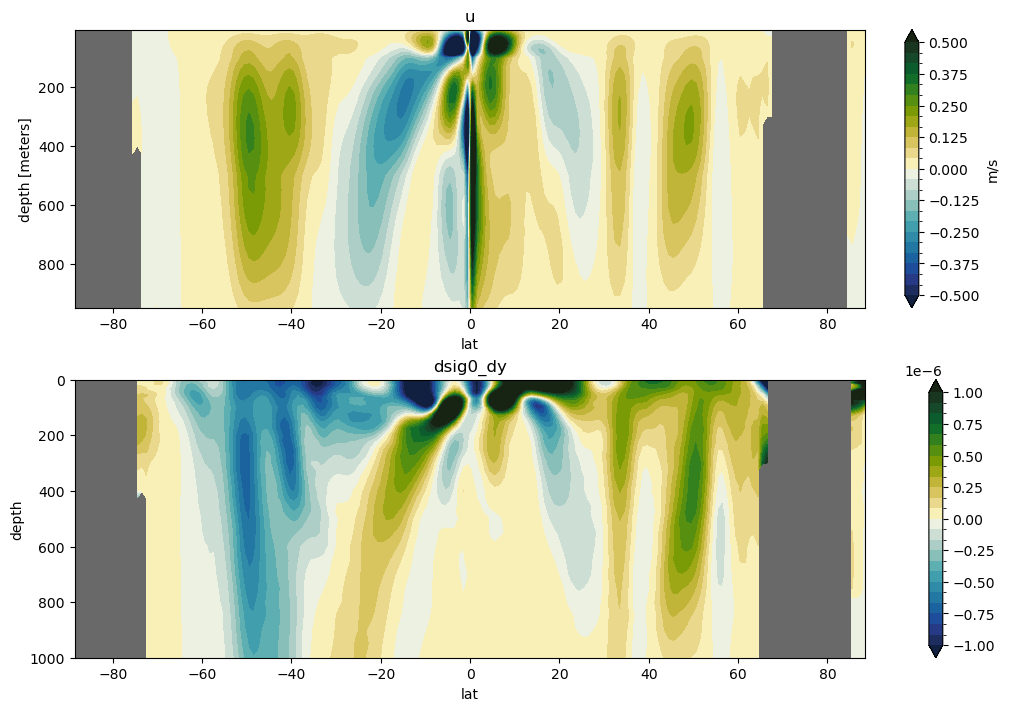

In [35]:
fig, ax = plt.subplots(figsize=(10,7),
                       nrows=2,
                       layout='constrained',
                       subplot_kw={
                           'facecolor':'dimgrey'},
                           )

u30W_upper1000.plot.contourf(ax=ax[0],
                             x='lat',
                             y='depth',
                             yincrease=False,
                             vmax=.5,
                             vmin=-.5,
                             levels=25,
                             cmap=cmocean.cm.delta,
                             cbar_kwargs={'label':"m/s"}
                            )
ax[0].set_title('u')
ax[0].set_xlabel('lat')

#
dsig0_30W_dy.sel(depth=slice(0,1000)).plot.contourf(ax=ax[1],
                                                    yincrease=False,
                                                    vmax=1e-6,
                                                    vmin=-1e-6,
                                                    levels=25,
                                                    cmap=cmocean.cm.delta
                                                   )
ax[1].set_title('dsig0_dy')


### todo: redo the above calculation starting at z = -3000 m and then again at the seafloor

In [37]:
# upper 3000
# step 1: ignore below 3000 m
du_dz30W_upper3000 = du_dz30W.sel(depth=slice(0,3000))

# step 2: vertical sum from 3000 to surface at all lats
du_dz30W_upper3000_flip = du_dz30W_upper3000.sortby('depth', ascending=False) # reverse z to integ from bottom to top
du_dz30W_upper3000_integ = du_dz30W_upper3000_flip.cumsum('depth')

# step 3: mult right side (above) by dz
dz_upper3000_idx = xr.DataArray((du_dz30W_upper3000.depth.values[2:] - du_dz30W_upper3000.depth.values[:-2])).rename({'dim_0': 'depth_index'}) # center dif dz
dz_upper3000 = (dz_upper3000_idx.assign_coords({
    'depth_index': ('depth_index', du_dz30W_upper3000.depth.values[1:-1]) # sliceing to match len bc of center dif method
}).rename({'depth_index': 'depth'})).depth

u30W_upper3000 = du_dz30W_upper3000_integ[:,1:-1] * dz_upper3000.sortby('depth', ascending=False).values # sel all lats and centered dif z spots to match dz
                                                                    # flipping dz to match order of du_dz30W_upper3000_integ
u30W_upper3000 = u30W_upper3000.where(sig_30W.notnull()) # mask out nans for land



# full column
# step 1: vertical sum from 1000 to surface at all lats
du_dz30W_alldepth_flip = du_dz30W.sortby('depth', ascending=False) # reverse z to integ from bottom to top
du_dz30W_alldepth_integ = du_dz30W_alldepth_flip.cumsum('depth')

# step 2: mult right side (above) by dz
dz_alldepth_idx = xr.DataArray((du_dz30W.depth.values[2:] - du_dz30W.depth.values[:-2])).rename({'dim_0': 'depth_index'}) # center dif dz
dz_alldepth = (dz_alldepth_idx.assign_coords({
    'depth_index': ('depth_index', du_dz30W.depth.values[1:-1]) # sliceing to match len bc of center dif method
}).rename({'depth_index': 'depth'})).depth

u30W_alldepth = du_dz30W_alldepth_integ[:,1:-1] * dz_alldepth.sortby('depth', ascending=False).values # sel all lats and centered dif z spots to match dz
                                                                  
u30W_alldepth = u30W_alldepth.where(sig_30W.notnull()) # mask out nans for land


### todo: consider how estimates of $u$ over the upper 1000 m change as the refence level deepends. Write a few sentences about these differences, describe the features of $u$ that you observe, and connect them to know currents. 

Text(0.5, 1.0, 'dsig0_dy')

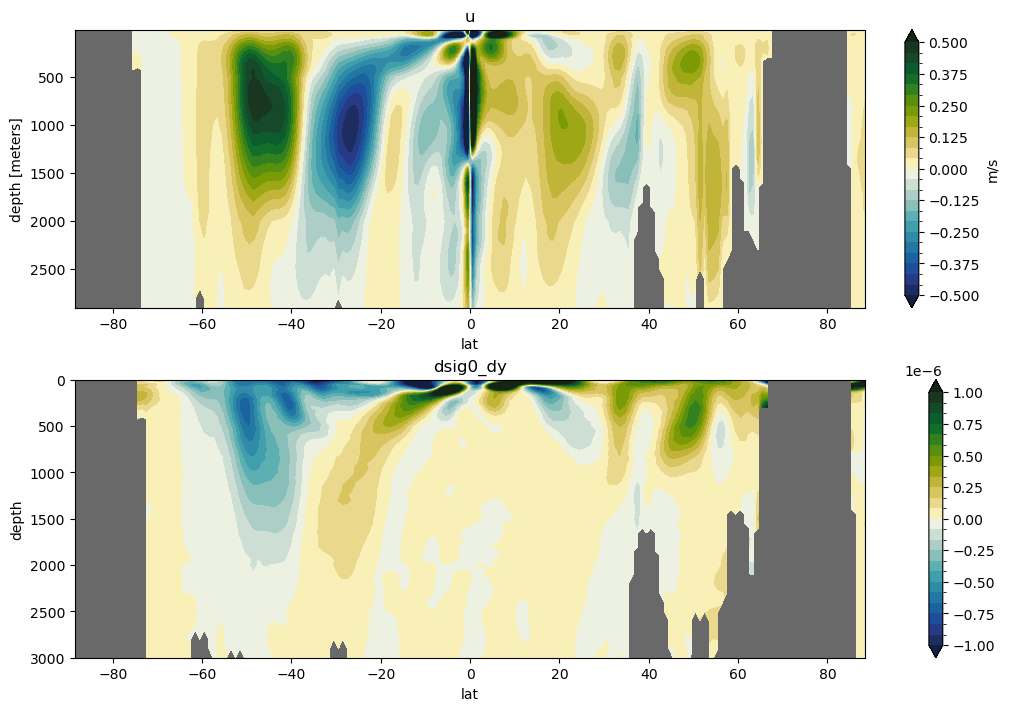

In [40]:
fig, ax = plt.subplots(figsize=(10,7),
                       nrows=2,
                       layout='constrained',
                       subplot_kw={
                           'facecolor':'dimgrey'},
                           )

u30W_upper3000.plot.contourf(ax=ax[0],
                             x='lat',
                             y='depth',
                             yincrease=False,
                             vmax=.5,
                             vmin=-.5,
                             levels=25,
                             cmap=cmocean.cm.delta,
                             cbar_kwargs={'label':"m/s"}
                            )
ax[0].set_title('u')
ax[0].set_xlabel('lat')

#
dsig0_30W_dy.sel(depth=slice(0,3000)).plot.contourf(ax=ax[1],
                                                    yincrease=False,
                                                    vmax=1e-6,
                                                    vmin=-1e-6,
                                                    levels=25,
                                                    cmap=cmocean.cm.delta
                                                   )
ax[1].set_title('dsig0_dy')


Text(0.5, 1.0, 'dsig0_dy')

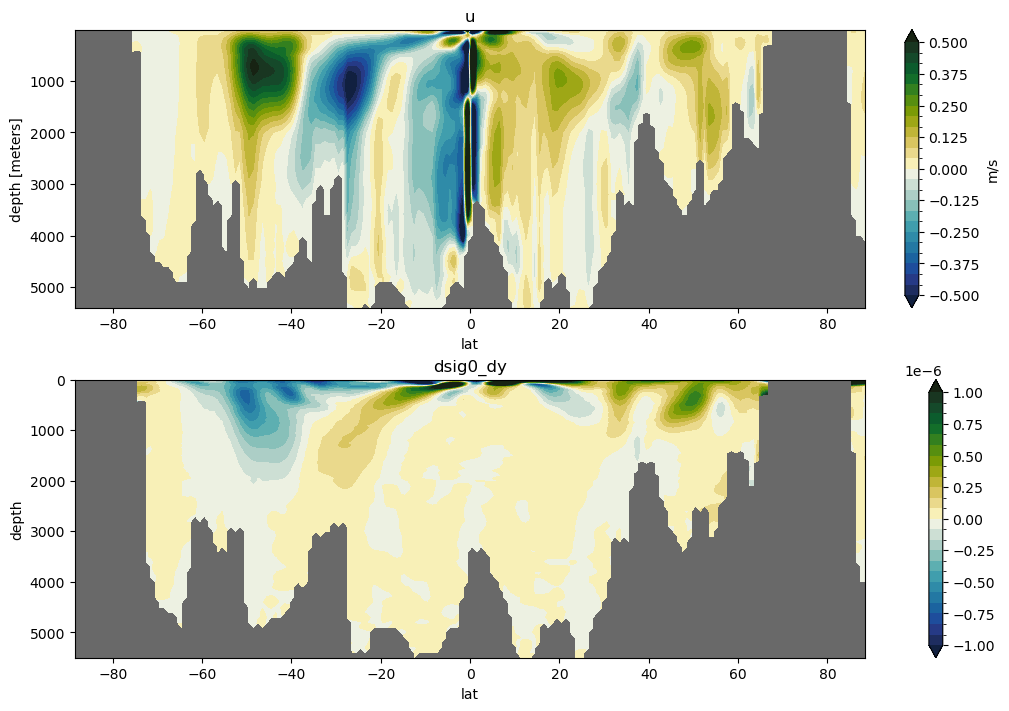

In [41]:
fig, ax = plt.subplots(figsize=(10,7),
                       nrows=2,
                       layout='constrained',
                       subplot_kw={
                           'facecolor':'dimgrey'},
                           )

u30W_alldepth.plot.contourf(ax=ax[0],
                             x='lat',
                             y='depth',
                             yincrease=False,
                             vmax=.5,
                             vmin=-.5,
                             levels=25,
                             cmap=cmocean.cm.delta,
                             cbar_kwargs={'label':"m/s"}
                            )
ax[0].set_title('u')
ax[0].set_xlabel('lat')

#
dsig0_30W_dy.plot.contourf(ax=ax[1],
                                                    yincrease=False,
                                                    vmax=1e-6,
                                                    vmin=-1e-6,
                                                    levels=25,
                                                    cmap=cmocean.cm.delta
                                                   )
ax[1].set_title('dsig0_dy')
